# NOTE
## 9.1 进行误差分析
假如狗类样本所占比重仅为8%，即时我们花费几个月的时间扩大狗类样本，提升模型对其识别率改进后的模型也没有显著改善。我们把这种性能限制称为ceiling on performance。我们要着重改善那些错误率高的。   
可以用一个表格记录所有的分错类的数量，计算不同类别中的误判个数，在此过程中还可以提出新的错误类别。这样有助于你判断优先级
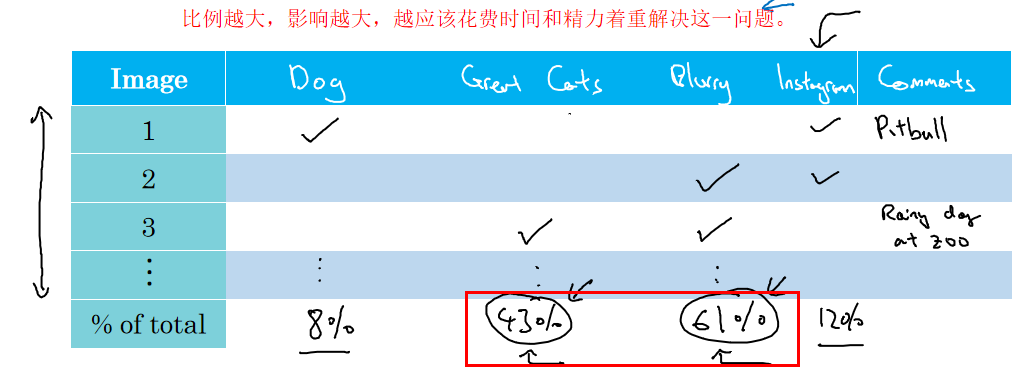

## 9.2 清理错误标注的数据
一个错误标记的例子：1是猫 0不是猫。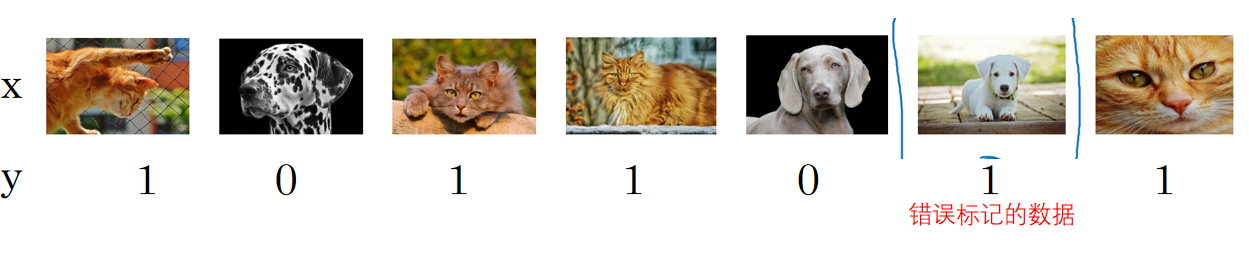

在训练集中：
- <font color='red'>DL algorithms are quite robust to random errors in the training set.   </font>
实际上，深度学习算法对训练集中的随机错误很稳健。只要你错误标记的例子不是那么偏离随机分布，比如只是由标记的人偶然的疏忽造成的。那么我们不用花费太多时间去纠正它们。所以只要总数据量够大，而实际错误标记的数据占比不高，就问题不大。
- 算法对随机误差很稳健，但是对系统误差不那么稳健。比如标记员**一直**把白色的狗标记为猫，那就会产生问题！

在开发集中：
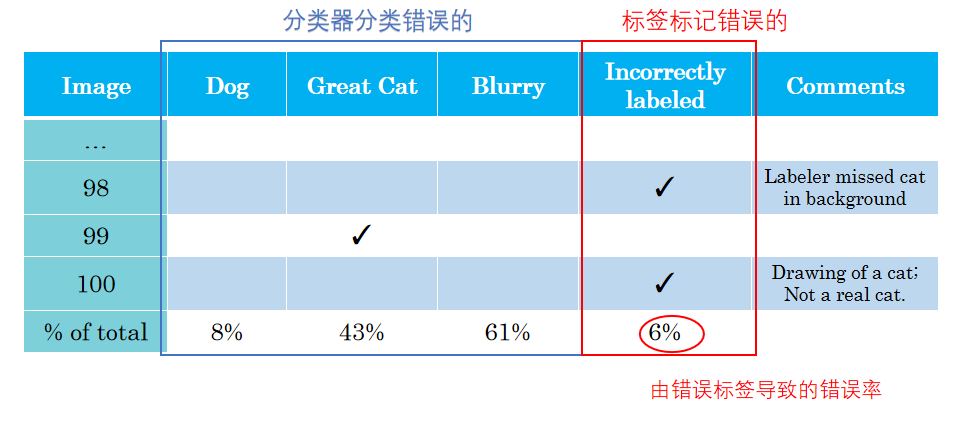
A：我们值得花费时间去纠正6%错误标记的例子吗？    
Q：如果这些错误对评估算法在开发集上的效果有很大的影响的话，那就花时间纠正这些错误。否则不用。比如在上图中，总体开发集错误率（Overall dev set error）：10%，由于错误标签导致的错误（Errors due incorrect labels）：10\*6%=0.6%，所以由于其他原因导致的错误（Errors due to other causes）：10%-0.6%=9.4%。这表明大多数错误是由其他原因引起的。因此相比之下，关注其他导致错误的原因，可能会对整体错误率的改进有更大的帮助。

wed认为，构造实用的系统时，通常人工错误分析和人的见解所占的比例比大部分研究者认为的要多。

## 9.3 快速构建你的第一个系统 并进行迭代
如果你正在第一次研究一个新问题，应该迅速构建你的第一个系统，然后进行迭代
1. 快速建立一个开发/测试集，以及度量指标。这决定了你的目标在哪里，如果发现出错了，始终可以移动目标。
2. 快速建立一个初步的简单的机器学习系统。
3. 用偏差/方差分析，还有错误分析。去区分以下几步工作的优先级。

\* 当然，如果你在该领域经验丰富或者这个领域有很多可以参考的学术论文，以上就不适用。

## 9.4 训练和测试的不同分布

方法一：打乱顺序，混合所有的

- **优点**：所有数据来自同一分布，易于管理
- **缺点**：开发集的瞄准目标能力不强。所以一般不建议

方法二：

例如，将200,000例网页图片和5,000例移动应用图片组合成训练集，剩下的2,500例移动应用图片作为开发集，2,500例移动应用图片作为测试集。

- 其关键在于开发集和测试集全部来自于移动应用。
- 这样保证了验证集最接近实际应用场合。这种方法较为常用，而且性能表现比较好。


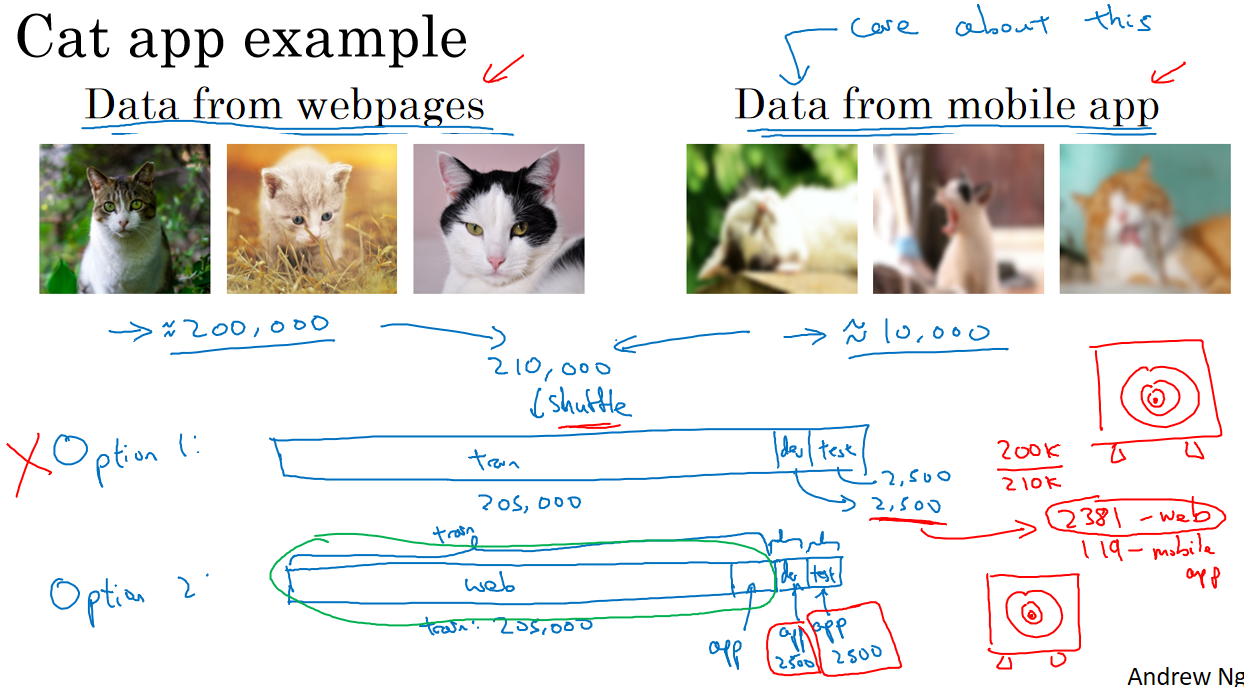

## 9.5 不匹配数据分布的偏差和方差
之前介绍过，根据human-level error、training error和dev error的相对值可以判定是否出现了bias或者variance。但是，需要注意的一点是，之前的前提是数据来源同分布。但如果train set和dev/test set来源于不同分布，则无法直接根据相对值大小来判断。**这时候就要设置train-dev set**   
train-dev set：从训练集中分离出来的一部分数据，用于在训练过程中进行验证，确保模型没有过拟合训练数据。train-dev set不用预训练数据，是与dev set一样**用于验证**。
- train set和train-dev set误差较大，虽然他俩都是同分布，但是网络只看到train set而没有看到train-dev set，说明一般性不好，方差较大。
- 而开发集的分配不一样，即使在训练集训练的很好，算法也并未在我们所关心的分布上，所以是数据不匹配问题。

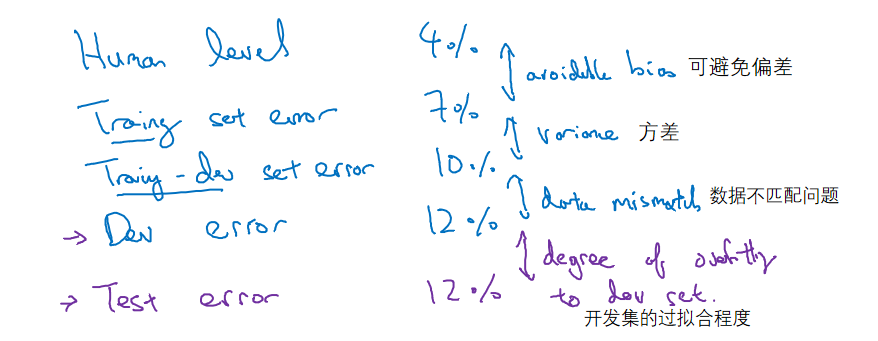
- 注意，开发集和测试集应该符合相同分布。如果测试集误差比开发集大很多，那就说明开发集过拟合了，我们应该**获取更多的开发集数据。**

这样一来，train-dev和train set 有相同的分布，之间的误差差值就可以看出方差是多少，而开发集和train-dev集都是用于验证，唯一差别就是数据分布不同，那么它们之间的差值就可以数据不匹配程度。大差值就表示训练数据和开发数据的分布差异较大，数据不匹配程度高

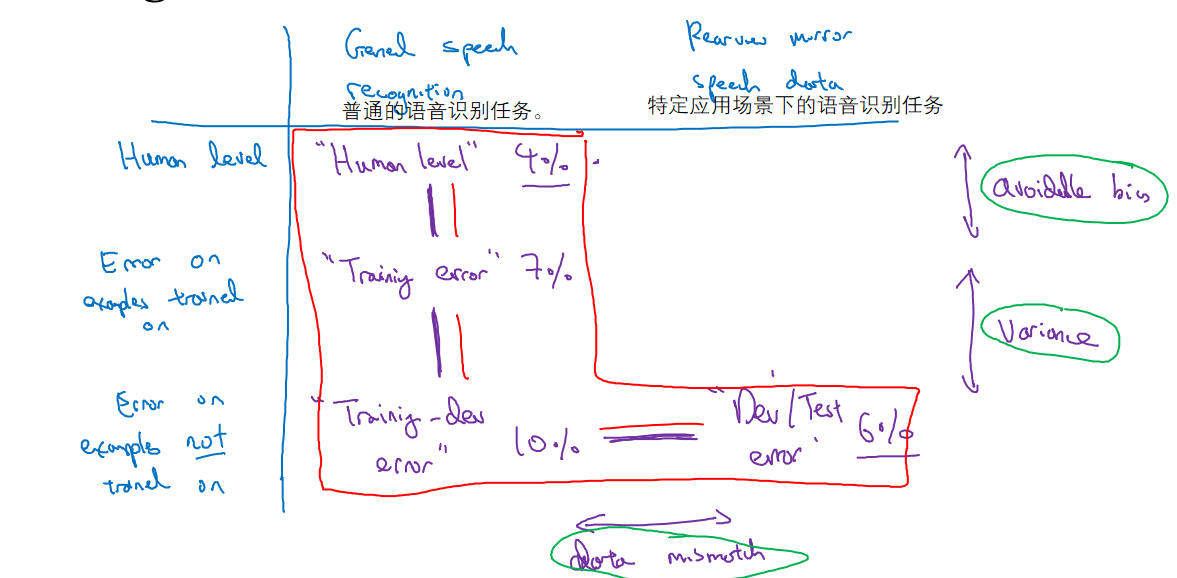

## 9.6 解决数据不匹配问题

如果发生了严重的数据不匹配问题。通常会人工分析误差，并试图理解训练集与开发/测试集之间的差异。并且我们应该找到更多开起来更像开发集的训练数据。


以下为可供参考的解决方案：

- 人工差别分析：当我们甄别到存在数据不匹配问题时则说明 train set 与 dev/test set 之间存在较大的差别。基于以上观点，我们可以观察这些数据差别究竟在哪里并为后面的工作指明方向。
- artificial data synthesis人工数据合成：基于差别分析我们可以认识到数据差异在何处。还是以之前的“车载导航”系统为例，假设经过分析我们认识当其他语料背景下的信息与车载语料背景下信息的最大差异在于车载语料背景存在很多的噪音。在这种情况下，我们可以通过信息合成的手段（synthesis）制造符合分布期望的数据集。需要注意的是，如果我们的制造方式不合理可能出现其他问题，如对特定的噪声特别敏感等等。（我们不能给每段语音都增加同一段背景噪声，这样会出现对背景噪音的过拟合，效果不佳。

## 9.7 迁移学习Transfer Learning

深度学习非常强大的一个功能之一就是有时候你可以将已经训练好的模型的一部分知识（网络结构）直接应用到另一个类似模型中去。比如我们已经训练好一个猫类识别的神经网络模型，那么我们可以直接把该模型中的一部分网络结构应用到使用X光片预测疾病的模型中去。这种学习方法被称为迁移学习（Transfer Learning）   

如果有一个小规模的数据集，那么就去重新训练最后一层和输出层的神经网络。或者训练最后一到两层的神经网络。   
但是如果有大量数据，可以对网络中的所有参数进行训练，这种情况下，训练的初始化阶段，被叫做**预训练pre-training**。之后对参数的调整叫做**微调fine-tuning**   
这样的过程是有用的，因为从大规模的图像识别数据集中学习到的边界检测、曲线检测等低层次信息会帮助我们再其他过程中学习到更多信息。
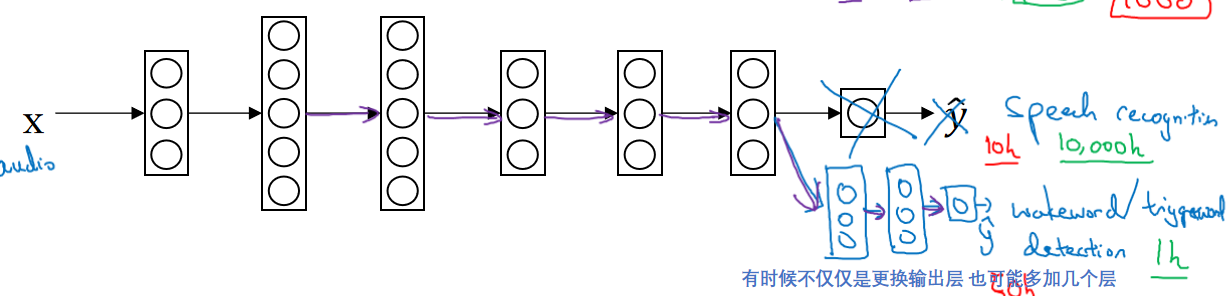

**什么时候迁移学习有用？**   
   
   
当你的被迁移的模型中拥有大量的数据，而你需要在解决的问题上用用相对较少的数据时。简单来说就是把一个有大量数据的问题模型，迁移到了一个相对之下仅有很少数据的问题模型中。如果数据被点到，那么迁移学习就不适用。   



**总体来说，迁移学习的应用场合主要包括以下三点：**

- 任务 A 和任务 B 具有相同的输入 x
    - 这意味着两个任务处理的数据类型是相同的，比如它们都处理图像、文本或音频等相同类型的数据。由于输入的性质相同，任务 A 学到的特征可以直接应用到任务 B 上。

- 任务 A 拥有比任务 B 多得多的数据
    - 通常情况下，任务 A 有一个大规模的数据集，而任务 B 的数据集相对较小。通过在任务 A 上进行预训练，可以利用大量数据学到的知识，从而在任务 B 上达到更好的效果。

- 任务 A 的低层次特征对学习任务 B 有帮助
     - 次特征通常包括边缘检测、纹理识别、基本形状识别等。在任务 A 中学到的这些特征往往具有通用性，可以有效地用于任务 B 的学习，从而提升任务 B 的表现。